# TreeFlow likelihood/ratio-transform benchmarks

This notebook is the inlined, BEAST-free replacement for the
[`treeflow-benchmarks`](https://github.com/christiaanjs/treeflow-benchmarks)
Snakemake pipeline that produced the benchmark figure (Fig 7) in the TreeFlow
paper. Differences from that pipeline:

* **No BEAST 2 / Feast dependency.** Coalescent tree topologies and DNA
  sequence alignments are simulated entirely with treeflow
  (`experiments/benchmarks/simulate.py`) instead of shelling out to `beast`.
  `ConstantCoalescent`'s `_sample_n` is a placeholder ("Dummy sampling") in
  treeflow today, so `simulate_coalescent_tree` implements the standard
  forwards-in-time coalescent waiting-time algorithm directly; sequences are
  simulated by calling `treeflow.model.phylo_model.get_sequence_distribution`
  (the same function that builds production likelihoods) and sampling from it.
* **A Jupyter notebook instead of Snakemake + R.** All simulation,
  benchmarking, data aggregation and plotting happens here. Log-log scaling
  fits use `numpy.polyfit` instead of R's `lm`.
* **A native-ops comparison.** `treeflow_native` reuses the exact same
  `TreeflowLikelihoodBenchmarkable`/`TreeflowRatioTransformBenchmarkable`
  classes as `treeflow`, just with `use_native=True` -- both `LeafCTMC` and
  `NodeHeightRatioBijector` already support routing through treeflow's
  compiled C++ ops (`treeflow.acceleration.native`), so this is a one-line
  toggle rather than a new implementation.
* **JAX (via [phylojax](https://github.com/christiaanjs/phylojax)) runs if
  installed**, and BEAGLE/[bito](https://github.com/phylovi/bito) runs if
  installed -- both are optional and the sweep skips them gracefully
  otherwise.

Supporting code lives in `experiments/benchmarks/`:

| module | contents |
| --- | --- |
| `simulate.py` | coalescent tree + sequence simulation, FASTA/newick writers |
| `params.py` | parameter-dict plumbing shared by the benchmarkables |
| `benchmarking.py` | generic timing harness (`LikelihoodBenchmarkable`, `RatioTransformBenchmarkable`) |
| `benchmarkables.py` | treeflow / treeflow-native / jax / beagle-bito implementations |
| `runner.py` | simulate -> benchmark sweep -> long-format `pandas.DataFrame` |


In [1]:
import sys
from pathlib import Path

# Make `experiments/benchmarks` importable as the `benchmarks` package,
# regardless of the notebook's working directory.
_experiments_dir = Path.cwd()
if not (_experiments_dir / "benchmarks").exists():
    _experiments_dir = Path.cwd() / "experiments"
sys.path.insert(0, str(_experiments_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from benchmarks.benchmarkables import bito_available, phylojax_available
from benchmarks.runner import fit_log_log_lines, run_likelihood_sweep, run_ratio_transform_sweep

print("phylojax available:", phylojax_available())
print("bito/BEAGLE available:", bito_available())

I0000 00:00:1783737636.124789    7119 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783737636.125713    7119 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783737636.209713    7119 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1783737638.525993    7119 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783737638.526688    7119 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Silencing TensorFlow...


phylojax available: True
bito/BEAGLE available: False


## Configuration

The manuscript figure used `taxon_counts = [32, 64, 128, 256, 512, 1024, 2048]`
with 10 replicates per taxon count (see the old pipeline's `config.yaml`). That
full sweep takes hours (particularly the per-sample Python-level gradient
loop at 2048 taxa) and needs BEAGLE/bito installed for every method to run, so
the config below defaults to a smaller demonstration sweep that exercises every
method end to end in a couple of minutes. Bump `TAXON_COUNTS`, `REPLICATES`,
`SAMPLE_COUNT` and `SEQUENCE_LENGTH` back up to the manuscript values to
reproduce Fig 7 exactly -- the rest of the notebook is unchanged either way.

In [2]:
TAXON_COUNTS = [8, 16, 32, 64, 128]  # manuscript: [32, 64, 128, 256, 512, 1024, 2048]
REPLICATES = 3  # manuscript: 10
SEEDS = list(range(1, REPLICATES + 1))
SEQUENCE_LENGTH = 200  # manuscript: 1000
REPEATS = 10  # timed repeats of a single fixed input per (taxon_count, seed, method)
POP_SIZE = 4.0
SAMPLING_WINDOW = 2.0
WORKING_DIR = "benchmarks/data/sim"

SIM_MODEL = dict(
    tree=dict(coalescent_constant=dict(pop_size=POP_SIZE)),
    clock=dict(strict=dict(clock_rate=0.01)),
    site="none",
    substitution="jc",
)

MODELS = dict(
    jc=dict(
        tree=dict(coalescent_constant=dict(pop_size=POP_SIZE)),
        clock=dict(strict=dict(clock_rate=0.01)),
        site="none",
        substitution="jc",
    ),
    full=dict(
        tree=dict(coalescent_constant=dict(pop_size=POP_SIZE)),
        clock=dict(strict=dict(clock_rate=0.01)),
        site=dict(discrete_weibull=dict(site_weibull_concentration=2.0, category_count=4)),
        substitution=dict(
            gtr=dict(
                frequencies=[0.24, 0.26, 0.27, 0.23],
                gtr_rates=[0.12, 0.17, 0.18, 0.11, 0.22, 0.20],
            )
        ),
    ),
)
CALCULATE_CLOCK_RATE_GRADIENT = dict(jc=False, full=True)

## Simulate and benchmark

Each `(taxon_count, seed)` combination gets one simulated tree + alignment. Every available likelihood benchmarkable is timed on that tree's *own* (single, fixed) branch lengths, repeated `REPEATS` times -- the traversal cost doesn't depend on the branch-length values themselves, so repeating one input and reporting both the `mean` and the `min` across repeats gives a far more stable estimate of per-call cost than timing a single call per input would (see `benchmarking.repeated_times`). Every available ratio-transform benchmarkable is timed the same way on that tree's own node-height ratios.

In [3]:
likelihood_data = run_likelihood_sweep(
    taxon_counts=TAXON_COUNTS,
    seeds=SEEDS,
    models=MODELS,
    calculate_clock_rate_gradient=CALCULATE_CLOCK_RATE_GRADIENT,
    pop_size=POP_SIZE,
    sampling_window=SAMPLING_WINDOW,
    sequence_length=SEQUENCE_LENGTH,
    repeats=REPEATS,
    sim_model=SIM_MODEL,
    working_dir=WORKING_DIR,
)
likelihood_data["task"] = "likelihood"
likelihood_data.tail()

E0000 00:00:1783737640.200150    7119 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


E0000 00:00:1783737640.670325    7119 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


,method,seed,taxon_count,model,stat,computation,time,task
475,treeflow_native,3,128,full,min,gradient_time,0.007409,likelihood
476,jax,3,128,full,mean,gradient_time,2.496174,likelihood
477,jax,3,128,full,min,gradient_time,2.050849,likelihood
478,jax_jit,3,128,full,mean,gradient_time,0.001170,likelihood
479,jax_jit,3,128,full,min,gradient_time,0.001100,likelihood


In [4]:
ratio_transform_data = run_ratio_transform_sweep(
    taxon_counts=TAXON_COUNTS,
    seeds=SEEDS,
    pop_size=POP_SIZE,
    sampling_window=SAMPLING_WINDOW,
    repeats=REPEATS,
    sim_model=SIM_MODEL,
    working_dir=WORKING_DIR,
)
ratio_transform_data["task"] = "ratio_transform"
ratio_transform_data.tail()

,method,seed,taxon_count,model,stat,computation,time,task
115,treeflow_native,2,128,none,min,gradient_time,0.000549,ratio_transform
116,treeflow,3,128,none,mean,gradient_time,0.001355,ratio_transform
117,treeflow,3,128,none,min,gradient_time,0.001236,ratio_transform
118,treeflow_native,3,128,none,mean,gradient_time,0.000596,ratio_transform
119,treeflow_native,3,128,none,min,gradient_time,0.000558,ratio_transform


## Assemble and save the plot data

This reproduces the old pipeline's `out/plot-data.csv` (long format: `method`, `seed`, `taxon_count`, `model`, `computation`, `time`) and `out/fit-table.csv` (log-log scaling exponents).

In [5]:
plot_data = pd.concat([likelihood_data, ratio_transform_data], ignore_index=True)

data_dir = Path("benchmarks/data")
data_dir.mkdir(parents=True, exist_ok=True)
plot_data.to_csv(data_dir / "plot-data.csv", index=False)

fit_table = fit_log_log_lines(plot_data)
fit_table.to_csv(data_dir / "fit-table.csv", index=False)
fit_table

,method,computation,model,stat,slope,intercept
0,jax,gradient_time,full,mean,0.856462,-3.410664
1,jax,gradient_time,full,min,0.809877,-3.343641
2,jax,gradient_time,jc,mean,1.051818,-4.488140
3,jax,gradient_time,jc,min,1.024810,-4.457616
4,jax,likelihood_time,full,mean,0.840253,-5.511420
5,jax,likelihood_time,full,min,0.840771,-5.559422
6,jax,likelihood_time,jc,mean,0.981081,-6.177109
7,jax,likelihood_time,jc,min,0.984915,-6.236476
8,jax_jit,gradient_time,full,mean,0.717051,-10.954725
9,jax_jit,gradient_time,full,min,0.742497,-11.230557


## Summary plots

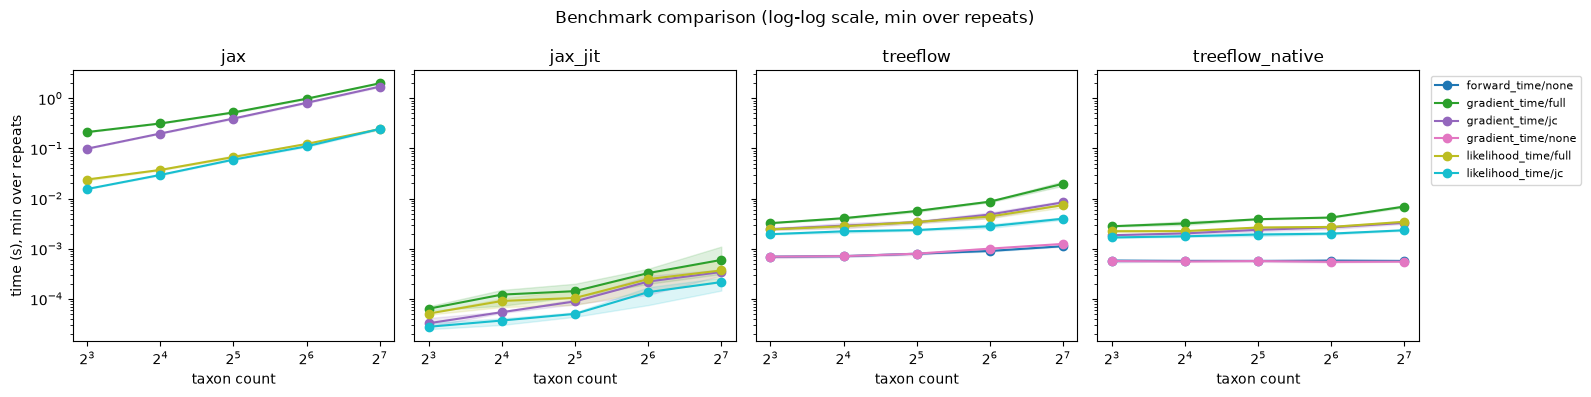

In [6]:
def comparison_plot(df, stat="min", log_scales=True, title=""):
    """Per-method panels of time vs. taxon count, coloured by computation/model
    -- a matplotlib equivalent of the old pipeline's R `comparisonPlot`. Uses a
    single `stat` ("mean" or "min") so each line reflects one timing summary;
    see the dedicated mean-vs-min comparison below for how the two differ."""
    df = df[df["stat"] == stat]
    methods = sorted(df["method"].unique())
    fig, axes = plt.subplots(1, len(methods), figsize=(4 * len(methods), 4), sharey=log_scales)
    if len(methods) == 1:
        axes = [axes]
    groups = [key for key, _ in df.groupby(["computation", "model"])]
    colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))
    for ax, method in zip(axes, methods):
        method_df = df[df["method"] == method]
        for (computation, model), color in zip(groups, colors):
            group_df = method_df[(method_df["computation"] == computation) & (method_df["model"] == model)]
            summary = group_df.groupby("taxon_count")["time"].agg(["mean", "min", "max"])
            if summary.empty:
                continue
            ax.plot(summary.index, summary["mean"], "o-", color=color, label=f"{computation}/{model}")
            ax.fill_between(summary.index, summary["min"], summary["max"], color=color, alpha=0.15)
        if log_scales:
            ax.set_xscale("log", base=2)
            ax.set_yscale("log")
        ax.set_title(method)
        ax.set_xlabel("taxon count")
    axes[0].set_ylabel(f"time (s), {stat} over repeats")
    axes[-1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
    fig.suptitle(title)
    fig.tight_layout()
    return fig


fig = comparison_plot(plot_data, stat="min", log_scales=True, title="Benchmark comparison (log-log scale, min over repeats)")
fig.savefig(data_dir / "log-scale-plot.png", dpi=150, bbox_inches="tight")
plt.show()

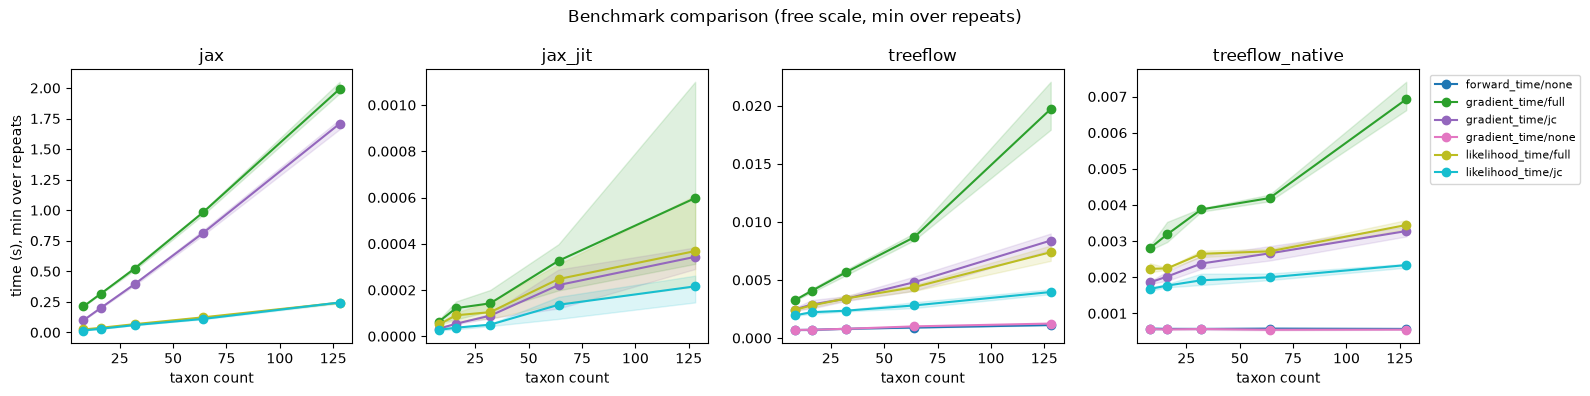

In [7]:
fig = comparison_plot(plot_data, stat="min", log_scales=False, title="Benchmark comparison (free scale, min over repeats)")
fig.savefig(data_dir / "free-scale-plot.png", dpi=150, bbox_inches="tight")
plt.show()

### Speedup relative to the plain TensorFlow-graph implementation

At the largest simulated taxon count, how much faster is each method than `treeflow` (no native ops)?

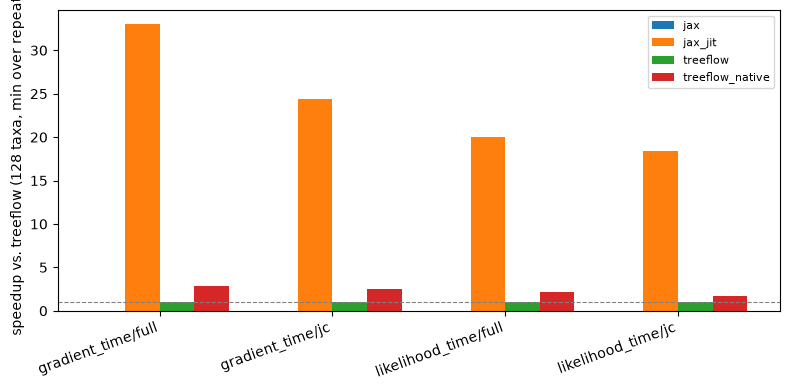

In [8]:
max_taxa = max(TAXON_COUNTS)
baseline = "treeflow"
subset = plot_data[
    (plot_data["taxon_count"] == max_taxa)
    & (plot_data["task"] == "likelihood")
    & (plot_data["stat"] == "min")
]
means = subset.groupby(["method", "computation", "model"])["time"].mean().unstack(["computation", "model"])
baseline_means = means.loc[baseline]
speedup = baseline_means / means

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(speedup.columns))
width = 0.8 / len(speedup.index)
for i, method in enumerate(speedup.index):
    ax.bar(x + i * width, speedup.loc[method].values, width=width, label=method)
ax.axhline(1.0, color="grey", lw=0.8, ls="--")
ax.set_xticks(x + width * (len(speedup.index) - 1) / 2)
ax.set_xticklabels(["/".join(c) for c in speedup.columns], rotation=20, ha="right")
ax.set_ylabel(f"speedup vs. {baseline} ({max_taxa} taxa, min over repeats)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(data_dir / "speedup-plot.png", dpi=150, bbox_inches="tight")
plt.show()

### Mean vs. min across repeats

Each `(taxon_count, method, computation)` cell was timed `REPEATS` times on the *same* fixed input. `min` discards positive scheduling/dispatch noise (it can only be an over-estimate of the true per-call cost, never an under-estimate), while `mean` is pulled upward by that noise -- the gap between them is itself a useful diagnostic: a small, stable gap means dispatch overhead is a minor fraction of the call; a large or taxon-count-dependent gap means overhead (not the traversal itself) is driving the measurement, which was exactly the problem with the earlier batch-of-different-inputs timing this replaced.

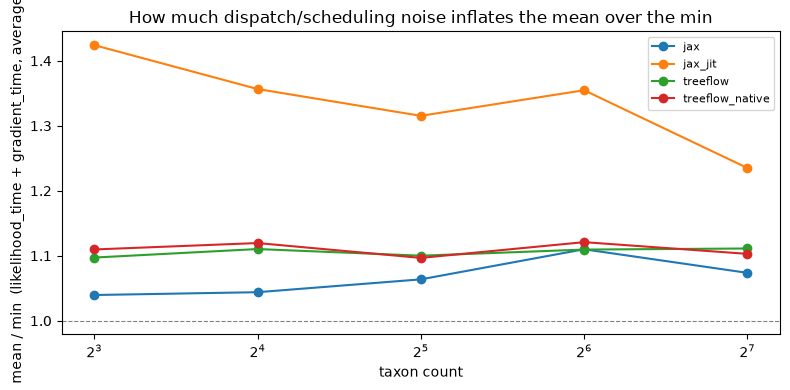

stat,method,computation,model,taxon_count,mean,min,mean_over_min
0,jax,gradient_time,full,8,0.219926,0.212310,1.035873
1,jax,gradient_time,full,16,0.324522,0.315023,1.030154
2,jax,gradient_time,full,32,0.587905,0.522394,1.125406
3,jax,gradient_time,full,64,1.156872,0.981879,1.178222
4,jax,gradient_time,full,128,2.276179,1.991662,1.142854
...,...,...,...,...,...,...,...
75,treeflow_native,likelihood_time,jc,8,0.001980,0.001677,1.180946
76,treeflow_native,likelihood_time,jc,16,0.002060,0.001769,1.164482
77,treeflow_native,likelihood_time,jc,32,0.002122,0.001916,1.107510
78,treeflow_native,likelihood_time,jc,64,0.002418,0.001999,1.209805


In [9]:
likelihood_min_mean = (
    plot_data[plot_data["task"] == "likelihood"]
    .pivot_table(index=["method", "computation", "model", "taxon_count"], columns="stat", values="time")
    .reset_index()
)
likelihood_min_mean["mean_over_min"] = likelihood_min_mean["mean"] / likelihood_min_mean["min"]

fig, ax = plt.subplots(figsize=(8, 4))
for method, group in likelihood_min_mean.groupby("method"):
    by_taxa = group.groupby("taxon_count")["mean_over_min"].mean()
    ax.plot(by_taxa.index, by_taxa.values, "o-", label=method)
ax.axhline(1.0, color="grey", lw=0.8, ls="--")
ax.set_xscale("log", base=2)
ax.set_xlabel("taxon count")
ax.set_ylabel("mean / min  (likelihood_time + gradient_time, averaged)")
ax.set_title("How much dispatch/scheduling noise inflates the mean over the min")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(data_dir / "mean-vs-min-plot.png", dpi=150, bbox_inches="tight")
plt.show()

likelihood_min_mean.sort_values(["method", "computation", "model", "taxon_count"])

### Log-log scaling exponents

Slope close to 1 is linear scaling in taxon count; treeflow's tree traversal is inherently linear, so values near 1 are expected for the likelihood and near/below 1 for the ratio transform.

In [10]:
fit_table.sort_values(["computation", "model", "method"])

,method,computation,model,stat,slope,intercept
16,treeflow,forward_time,none,mean,0.142039,-7.385096
17,treeflow,forward_time,none,min,0.173947,-7.697666
28,treeflow_native,forward_time,none,mean,0.011981,-7.339096
29,treeflow_native,forward_time,none,min,-0.002500,-7.455695
0,jax,gradient_time,full,mean,0.856462,-3.410664
1,jax,gradient_time,full,min,0.809877,-3.343641
8,jax_jit,gradient_time,full,mean,0.717051,-10.954725
9,jax_jit,gradient_time,full,min,0.742497,-11.230557
18,treeflow,gradient_time,full,mean,0.640017,-7.161599
19,treeflow,gradient_time,full,min,0.629794,-7.202120
